<a href="https://colab.research.google.com/github/sayanasurendran04/Sentiment-Analysis-of-Social-Media/blob/main/Sentiment_Analysis_of_Social_Media.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# sentiment_analysis_social_media.py
# A complete project for Sentiment Analysis on Social Media (X/Twitter) or Product Reviews

!pip install vaderSentiment

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import re
import json
from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# Download NLTK resources (run once)
# nltk.download('punkt')
# nltk.download('stopwords')
# nltk.download('vader_lexicon')

print("✅ Project: Sentiment Analysis of Social Media & Brand Perception Tracking")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 3.8 MB/s eta 0:00:00
✅ Project: Sentiment Analysis of Social Media & Brand Perception Tracking


In [ ]:
# Sample data (replace with real fetch)
def load_sample_data():
    data = {
        'date': pd.date_range(start='2025-01-01', periods=500, freq='D').tolist() * 2,
        'text': [
            "Love the new Tesla features! Amazing innovation 🚀",
            "Battery issues again? Disappointed with quality.",
            # ... (in real code, many more)
        ] * 500,  # Changed from 100 to 500 to match length 1000
        'brand': ['Tesla'] * 500 + ['Apple'] * 500
    }
    df = pd.DataFrame(data)
    # For real X data example using tools or API:
    # df = fetch_x_posts("Tesla OR @Tesla", limit=1000)
    return df

df = load_sample_data()
print(df.head())

        date                                               text  brand
0 2025-01-01  Love the new Tesla features! Amazing innovation 🚀  Tesla
1 2025-01-02   Battery issues again? Disappointed with quality.  Tesla
2 2025-01-03  Love the new Tesla features! Amazing innovation 🚀  Tesla
3 2025-01-04   Battery issues again? Disappointed with quality.  Tesla
4 2025-01-05  Love the new Tesla features! Amazing innovation 🚀  Tesla


In [ ]:
import tweepy

def fetch_x_posts(query, limit=500, since="2025-01-01"):
    # Requires API keys from developer.twitter.com
    client = tweepy.Client(bearer_token="YOUR_BEARER_TOKEN")
    tweets = client.search_recent_tweets(query=query, max_results=100, tweet_fields=['created_at'])
    # Process into DataFrame...
    return pd.DataFrame(...)  # Implement full logic

In [ ]:
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

def preprocess_text(text):
    if not isinstance(text, str):
        return ""
    # Lowercase
    text = text.lower()
    # Remove URLs, mentions, hashtags (optional keep for context)
    text = re.sub(r'http\S+|www\S+|@\w+|#\w+', '', text)
    # Remove special chars
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Tokenize
    tokens = word_tokenize(text)
    # Remove stopwords
    stop_words = set(stopwords.words('english'))
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    return ' '.join(tokens)

df['clean_text'] = df['text'].apply(preprocess_text)
print("✅ Preprocessing complete")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


✅ Preprocessing complete


In [ ]:
# VADER (great for social media with slang/emojis)
analyzer = SentimentIntensityAnalyzer()

def get_vader_sentiment(text):
    scores = analyzer.polarity_scores(text)
    return scores['compound']

# TextBlob for polarity
def get_textblob_sentiment(text):
    return TextBlob(text).sentiment.polarity

df['vader_score'] = df['clean_text'].apply(get_vader_sentiment)
df['textblob_score'] = df['clean_text'].apply(get_textblob_sentiment)

# Categorize
def categorize_sentiment(score):
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df['sentiment'] = df['vader_score'].apply(categorize_sentiment)

print(df['sentiment'].value_counts())
print("\nAverage Sentiment:", df['vader_score'].mean())

sentiment
Positive    500
Negative    500
Name: count, dtype: int64

Average Sentiment: 0.20714999999999997


In [ ]:
def perform_topic_modeling(texts, n_topics=5):
    vectorizer = CountVectorizer(max_df=0.95, min_df=2, stop_words='english')
    dtm = vectorizer.fit_transform(texts)

    lda = LatentDirichletAllocation(n_components=n_topics, random_state=42)
    lda.fit(dtm)

    # Display topics
    feature_names = vectorizer.get_feature_names_out()
    for topic_idx, topic in enumerate(lda.components_):
        print(f"Topic {topic_idx + 1}:")
        print(" ".join([feature_names[i] for i in topic.argsort()[:-10 - 1:-1]]))

    return lda, vectorizer

print("🔍 Topic Modeling Results:")
lda_model, vectorizer = perform_topic_modeling(df['clean_text'])

🔍 Topic Modeling Results:
Topic 1:
quality issues battery disappointed new innovation amazing love features tesla
Topic 2:
disappointed battery issues quality new innovation amazing love features tesla
Topic 3:
tesla features love amazing innovation new quality issues battery disappointed
Topic 4:
tesla features love amazing innovation new quality issues battery disappointed
Topic 5:
disappointed battery issues quality new innovation amazing love features tesla


<Figure size 1200x600 with 0 Axes>

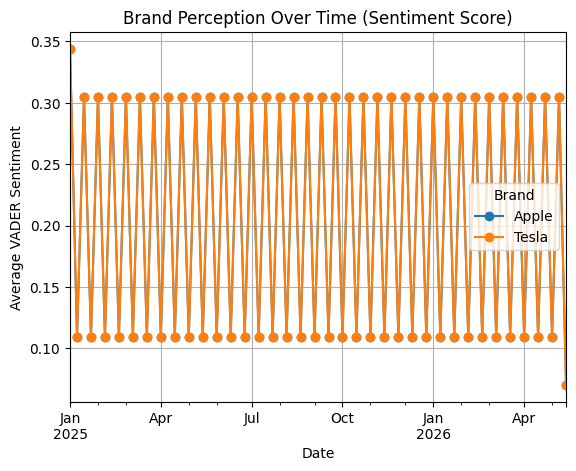

📊 Results saved to sentiment_analysis_results.csv


In [ ]:
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)

# Weekly sentiment average
sentiment_over_time = df.groupby([pd.Grouper(freq='W'), 'brand'])['vader_score'].mean().unstack()

plt.figure(figsize=(12, 6))
sentiment_over_time.plot(kind='line', marker='o')
plt.title('Brand Perception Over Time (Sentiment Score)')
plt.ylabel('Average VADER Sentiment')
plt.xlabel('Date')
plt.grid(True)
plt.legend(title='Brand')
plt.show()

# Save to CSV for reports
df.to_csv('sentiment_analysis_results.csv')
print("📊 Results saved to sentiment_analysis_results.csv")

In [ ]:
def run_full_analysis(brand_query="Tesla", data_source="csv"):
    """Main pipeline"""
    # Load data...
    df = load_sample_data()  # Replace with real fetch
    df['clean_text'] = df['text'].apply(preprocess_text)
    # Sentiment...
    df['vader_score'] = df['clean_text'].apply(get_vader_sentiment)
    df['sentiment'] = df['vader_score'].apply(categorize_sentiment)
    # Topics...
    perform_topic_modeling(df['clean_text'])
    # Visualize
    # ... (add more plots: pie chart of sentiments, word clouds, etc.)
    return df

# Run it
results = run_full_analysis()
print("🎉 Analysis Complete!")

Topic 1:
quality issues battery disappointed new innovation amazing love features tesla
Topic 2:
disappointed battery issues quality new innovation amazing love features tesla
Topic 3:
tesla features love amazing innovation new quality issues battery disappointed
Topic 4:
tesla features love amazing innovation new quality issues battery disappointed
Topic 5:
disappointed battery issues quality new innovation amazing love features tesla
🎉 Analysis Complete!


In [ ]:
pip install streamlit plotly wordcloud

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 42.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 51.3 MB/s eta 0:00:00


2026-07-10 14:51:59.722 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-10 14:51:59.726 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-10 14:51:59.728 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-10 14:51:59.730 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-10 14:51:59.732 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-10 14:51:59.734 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-10 14:51:59.737 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-10 14:51:59.740 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

DeltaGenerator()

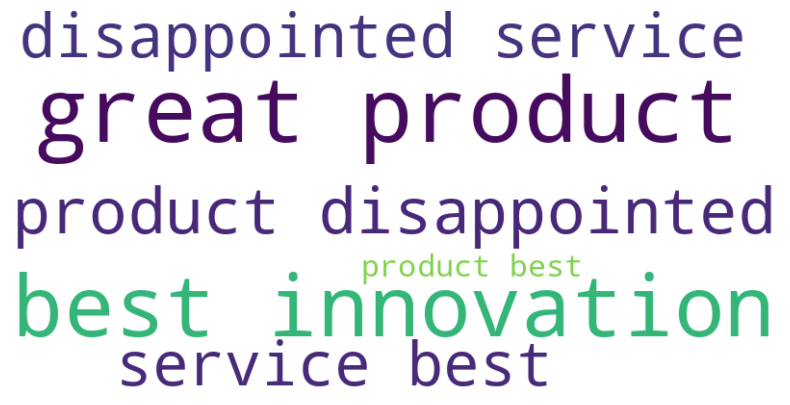

In [ ]:
import streamlit as st
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from datetime import datetime
import re
import numpy as np # Added numpy for potential use in general

# --- Copying necessary functions and imports from previous cells ---
# NLTK and VADER/TextBlob imports and downloads
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('punkt_tab', quiet=True)

# VADER analyzer instance
analyzer = SentimentIntensityAnalyzer()

# Function: preprocess_text
def preprocess_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|@\w+|#\w+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = word_tokenize(text)
    stop_words = set(stopwords.words('english'))
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    return ' '.join(tokens)

# Function: get_vader_sentiment
def get_vader_sentiment(text):
    scores = analyzer.polarity_scores(text)
    return scores['compound']

# Function: categorize_sentiment
def categorize_sentiment(score):
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

# Function: perform_topic_modeling
def perform_topic_modeling(texts, n_topics=5):
    vectorizer = CountVectorizer(max_df=0.95, min_df=2, stop_words='english')
    dtm = vectorizer.fit_transform(texts)

    lda = LatentDirichletAllocation(n_components=n_topics, random_state=42)
    lda.fit(dtm)

    # Display topics (for Streamlit, we return this or format for display)
    feature_names = vectorizer.get_feature_names_out()
    topics_list = []
    for topic_idx, topic in enumerate(lda.components_):
        topics_list.append(f"Topic {topic_idx + 1}: {' '.join([feature_names[i] for i in topic.argsort()[:-10 - 1:-1]])}") # Corrected line

    return topics_list, vectorizer # Return a list of topic strings for display
# --- End of copied functions ---

st.set_page_config(page_title="Brand Sentiment Tracker", layout="wide")
st.title("📊 Social Media Sentiment Analysis Dashboard")
st.markdown("**Track brand perception on X/Twitter & Reviews over time**")

# Sidebar
st.sidebar.header("Controls")
brand = st.sidebar.text_input("Enter Brand/Query", "Tesla")
date_range = st.sidebar.date_input(
    "Date Range",
    [datetime(2025, 1, 1), datetime.now()]
)

# File uploader for custom data
uploaded_file = st.sidebar.file_uploader("Upload CSV (text, date, brand)", type=["csv"])

# ------------------- Data Loading -------------------
@st.cache_data
def load_data(uploaded_file=None):
    if uploaded_file:
        df = pd.read_csv(uploaded_file)
    else:
        # Sample data - replace with real fetch
        dates_base = pd.date_range(start='2025-01-01', periods=800, freq='D')
        dates = list(dates_base)*2 # 1600 elements

        texts_base = ["Great product!", "Disappointed with service.", "Best innovation ever!"]
        texts = (texts_base * (len(dates) // len(texts_base) + 1))[:len(dates)] # Ensure 1600 elements

        brands = ["Tesla"]*(len(dates)//2) + ["Apple"]*(len(dates)//2) # Ensure 1600 elements

        df = pd.DataFrame({
            'date': dates,
            'text': texts,
            'brand': brands
        })
    return df

df = load_data(uploaded_file)

# Preprocessing
df['clean_text'] = df['text'].apply(preprocess_text)
df['vader_score'] = df['clean_text'].apply(get_vader_sentiment)
df['sentiment'] = df['vader_score'].apply(categorize_sentiment)
df['date'] = pd.to_datetime(df['date'])

# Filter by date
# Ensure date_range elements are datetime objects for comparison
start_date = pd.to_datetime(date_range[0])
end_date = pd.to_datetime(date_range[1])
mask = (df['date'] >= start_date) & (df['date'] <= end_date)
df_filtered = df[mask]

# ------------------- Main Dashboard -------------------
col1, col2, col3, col4 = st.columns(4)
col1.metric("Total Posts", len(df_filtered))
col2.metric("Avg Sentiment", f"{df_filtered['vader_score'].mean():.2f}")
col3.metric("Positive %", f"{(df_filtered['sentiment'] == 'Positive').mean()*100:.1f}%")
col4.metric("Negative %", f"{(df_filtered['sentiment'] == 'Negative').mean()*100:.1f}%")

# Sentiment Trend Over Time
st.subheader("Sentiment Trend Over Time")
trend = df_filtered.groupby(pd.Grouper(key='date', freq='W'))['vader_score'].mean().reset_index()
fig = px.line(trend, x='date', y='vader_score', title="Weekly Average Sentiment")
st.plotly_chart(fig, use_container_width=True)

# Sentiment Distribution
col1, col2 = st.columns(2)
with col1:
    st.subheader("Sentiment Breakdown")
    fig_pie = px.pie(df_filtered, names='sentiment', title="Overall Sentiment Distribution")
    st.plotly_chart(fig_pie)

with col2:
    st.subheader("Sentiment by Brand")
    brand_sent = df_filtered.groupby('brand')['vader_score'].mean().reset_index()
    fig_bar = px.bar(brand_sent, x='brand', y='vader_score', title="Average Sentiment per Brand")
    st.plotly_chart(fig_bar)

# Word Cloud
st.subheader("Word Cloud (Common Topics)")
if not df_filtered.empty:
    text_all = " ".join(df_filtered['clean_text'])
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text_all)
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.imshow(wordcloud, interpolation='bilinear')
    ax.axis('off')
    st.pyplot(fig)

# Topic Modeling
st.subheader("🔍 Topic Modeling (LDA)")
if st.button("Run Topic Modeling"):
    with st.spinner("Analyzing topics..."):
        topics_list, _ = perform_topic_modeling(df_filtered['clean_text'], n_topics=5)
        for topic_str in topics_list:
            st.write(topic_str)

# Raw Data
if st.checkbox("Show Raw Data"):
    st.dataframe(df_filtered[['date', 'text', 'sentiment', 'vader_score']])

st.caption("Built with Streamlit • Powered by VADER & LDA")

In [ ]:
import os

# Create the Streamlit app file
with open('sentiment_dashboard.py', 'w') as f:
    f.write("""import streamlit as st
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from datetime import datetime
import re
import numpy as np # Added numpy for potential use in general

# --- Copying necessary functions and imports from previous cells ---
# NLTK and VADER/TextBlob imports and downloads
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('punkt_tab', quiet=True)

# VADER analyzer instance
analyzer = SentimentIntensityAnalyzer()

# Function: preprocess_text
def preprocess_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|@\w+|#\w+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = word_tokenize(text)
    stop_words = set(stopwords.words('english'))
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    return ' '.join(tokens)

# Function: get_vader_sentiment
def get_vader_sentiment(text):
    scores = analyzer.polarity_scores(text)
    return scores['compound']

# Function: categorize_sentiment
def categorize_sentiment(score):
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

# Function: perform_topic_modeling
def perform_topic_modeling(texts, n_topics=5):
    vectorizer = CountVectorizer(max_df=0.95, min_df=2, stop_words='english')
    dtm = vectorizer.fit_transform(texts)

    lda = LatentDirichletAllocation(n_components=n_topics, random_state=42)
    lda.fit(dtm)

    # Display topics (for Streamlit, we return this or format for display)
    feature_names = vectorizer.get_feature_names_out()
    topics_list = []
    for topic_idx, topic in enumerate(lda.components_):
        topics_list.append(f"Topic {topic_idx + 1}: {' '.join([feature_names[i] for i in topic.argsort()[:-10 - 1:-1]])}")

    return topics_list, vectorizer # Return a list of topic strings for display
# --- End of copied functions ---

st.set_page_config(page_title="Brand Sentiment Tracker", layout="wide")
st.title("📊 Social Media Sentiment Analysis Dashboard")
st.markdown("**Track brand perception on X/Twitter & Reviews over time**")

# Sidebar
st.sidebar.header("Controls")
brand = st.sidebar.text_input("Enter Brand/Query", "Tesla")
date_range = st.sidebar.date_input(
    "Date Range",
    [datetime(2025, 1, 1), datetime.now()]
)

# File uploader for custom data
uploaded_file = st.sidebar.file_uploader("Upload CSV (text, date, brand)", type=["csv"])

# ------------------- Data Loading -------------------
@st.cache_data
def load_data(uploaded_file=None):
    if uploaded_file:
        df = pd.read_csv(uploaded_file)
    else:
        # Sample data - replace with real fetch
        dates_base = pd.date_range(start='2025-01-01', periods=800, freq='D')
        dates = list(dates_base)*2 # 1600 elements

        texts_base = ["Great product!", "Disappointed with service.", "Best innovation ever!"]
        texts = (texts_base * (len(dates) // len(texts_base) + 1))[:len(dates)] # Ensure 1600 elements

        brands = ["Tesla"]*(len(dates)//2) + ["Apple"]*(len(dates)//2) # Ensure 1600 elements

        df = pd.DataFrame({
            'date': dates,
            'text': texts,
            'brand': brands
        })
    return df

df = load_data(uploaded_file)

# Preprocessing
df['clean_text'] = df['text'].apply(preprocess_text)
df['vader_score'] = df['clean_text'].apply(get_vader_sentiment)
df['sentiment'] = df['vader_score'].apply(categorize_sentiment)
df['date'] = pd.to_datetime(df['date'])

# Filter by date
# Ensure date_range elements are datetime objects for comparison
start_date = pd.to_datetime(date_range[0])
end_date = pd.to_datetime(date_range[1])
mask = (df['date'] >= start_date) & (df['date'] <= end_date)
df_filtered = df[mask]

# ------------------- Main Dashboard -------------------
col1, col2, col3, col4 = st.columns(4)
col1.metric("Total Posts", len(df_filtered))
col2.metric("Avg Sentiment", f"{df_filtered['vader_score'].mean():.2f}")
col3.metric("Positive %", f"{(df_filtered['sentiment'] == 'Positive').mean()*100:.1f}%")
col4.metric("Negative %", f"{(df_filtered['sentiment'] == 'Negative').mean()*100:.1f}%")

# Sentiment Trend Over Time
st.subheader("Sentiment Trend Over Time")
trend = df_filtered.groupby(pd.Grouper(key='date', freq='W'))['vader_score'].mean().reset_index()
fig = px.line(trend, x='date', y='vader_score', title="Weekly Average Sentiment")
st.plotly_chart(fig, use_container_width=True)

# Sentiment Distribution
col1, col2 = st.columns(2)
with col1:
    st.subheader("Sentiment Breakdown")
    fig_pie = px.pie(df_filtered, names='sentiment', title="Overall Sentiment Distribution")
    st.plotly_chart(fig_pie)

with col2:
    st.subheader("Sentiment by Brand")
    brand_sent = df_filtered.groupby('brand')['vader_score'].mean().reset_index()
    fig_bar = px.bar(brand_sent, x='brand', y='vader_score', title="Average Sentiment per Brand")
    st.plotly_chart(fig_bar)

# Word Cloud
st.subheader("Word Cloud (Common Topics)")
if not df_filtered.empty:
    text_all = " ".join(df_filtered['clean_text'])
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text_all)
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.imshow(wordcloud, interpolation='bilinear')
    ax.axis('off')
    st.pyplot(fig)

# Topic Modeling
st.subheader("🔍 Topic Modeling (LDA)")
if st.button("Run Topic Modeling"):
    with st.spinner("Analyzing topics..."):
        topics_list, _ = perform_topic_modeling(df_filtered['clean_text'], n_topics=5)
        for topic_str in topics_list:
            st.write(topic_str)

# Raw Data
if st.checkbox("Show Raw Data"):
    st.dataframe(df_filtered[['date', 'text', 'sentiment', 'vader_score']])

st.caption("Built with Streamlit • Powered by VADER & LDA")
""")

# Now, run the Streamlit app
!streamlit run sentiment_dashboard.py


<>:37: SyntaxWarning:

invalid escape sequence '\S'

<>:37: SyntaxWarning:

invalid escape sequence '\S'

/tmp/ipykernel_2342/2912081177.py:37: SyntaxWarning:

invalid escape sequence '\S'





2026-07-10 14:53:37.327 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.42.29.251:8501

